# Predicting Earnings Manipulation by Indian Firms
### MCA Technologies Private Limited — Applied Business Analytics Group Assignment

**Business problem.** MCA Technologies wants a screening tool that flags Indian listed firms likely to be
manipulating earnings, so that scarce forensic-audit capacity is pointed at the right companies.

**Data.** 220 firms, 8 financial-ratio indices derived from consecutive years of published financials
(the Beneish variable set), plus a label.

| Variable | Meaning | Manipulation signal |
|---|---|---|
| DSRI | Days' Sales in Receivables Index | Receivables growing faster than sales → revenue inflation |
| GMI | Gross Margin Index | Margins deteriorating → pressure/motive to manipulate |
| AQI | Asset Quality Index | Rising share of soft (non-current, non-PPE) assets → cost capitalisation |
| SGI | Sales Growth Index | High growth → pressure to sustain the story |
| DEPI | Depreciation Index | Depreciation rate slowing → income inflated by revised useful life |
| SGAI | SG&A Index | SG&A rising faster than sales → deteriorating quality |
| ACCR | Accruals to Total Assets | Earnings not backed by cash |
| LEVI | Leverage Index | Rising leverage → debt-covenant motive |

**Target:** `C-MANIPULATOR` (1 = manipulator, 0 = non-manipulator).

In [1]:
# --- Libraries: data handling, statistics, ML, plotting ---
import pandas as pd
import numpy as np
import statsmodels.api as sm
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

In [2]:
# Load the case data. encoding='utf-8-sig' strips the BOM on the first column name.
DATA_PATH = 'Case Data NS.csv'      # <-- change if your filename differs
df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df.columns = [c.strip() for c in df.columns]
df.head()

,Company ID,DSRI,GMI,AQI,SGI,DEPI,SGAI,ACCR,LEVI,Manipulator,C-MANIPULATOR
0,1,1.6247,1.1289,7.1851,0.3662,1.3815,1.6241,-0.1668,1.1611,Yes,1
1,2,1.0000,1.6065,1.0050,13.0814,0.4000,5.1982,0.0605,0.9867,Yes,1
2,3,1.0000,1.0156,1.2414,1.4750,1.1694,0.6477,0.0367,1.2643,Yes,1
3,4,1.4862,1.0000,0.4655,0.6728,2.0000,0.0929,0.2734,0.6810,Yes,1
4,5,1.0000,1.3690,0.6371,0.8613,1.4547,1.7415,0.1230,0.9390,Yes,1


In [3]:
# Shape, types, missing values, target balance
print('Shape:', df.shape)
print()
df.info()
print('\nMissing values:', df.isnull().sum().sum())
print('\nTarget distribution:')
print(df['C-MANIPULATOR'].value_counts())
print(df['C-MANIPULATOR'].value_counts(normalize=True).round(4))

Shape: (220, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company ID     220 non-null    int64  
 1   DSRI           220 non-null    float64
 2   GMI            220 non-null    float64
 3   AQI            220 non-null    float64
 4   SGI            220 non-null    float64
 5   DEPI           220 non-null    float64
 6   SGAI           220 non-null    float64
 7   ACCR           220 non-null    float64
 8   LEVI           220 non-null    float64
 9   Manipulator    220 non-null    object 
 10  C-MANIPULATOR  220 non-null    int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 19.0+ KB

Missing values: 0

Target distribution:
C-MANIPULATOR
0    181
1     39
Name: count, dtype: int64
C-MANIPULATOR
0   0.8227
1   0.1773
Name: proportion, dtype: float64


---
# Q1. Modelling problems under class imbalance, and how to handle them  *(2 marks)*

In this sample only **39 of 220 firms (17.7%)** are manipulators, and in the underlying population the
rate is far lower still (roughly 3–4% of listed firms). Four things go wrong:

**1. The accuracy paradox / majority-class bias.** A model that predicts "no manipulation" for every firm
scores 82.3% accuracy here (and ~96% on the true population) while being completely useless. Because
maximum-likelihood estimation minimises *total* error, the fitted model is pulled toward the majority
class and sensitivity collapses.

**2. Unstable coefficient estimates.** The effective sample size for a logistic regression is driven by the
*rare* class. With 39 positives and 8 predictors we are close to the rule-of-thumb floor of ~10 events per
variable, so standard errors are wide and estimates are sensitive to which firms land in the test split.
Small-sample logistic MLE is also biased away from zero (Firth's separation problem).

**3. Poorly calibrated probabilities.** Predicted probabilities are systematically too low for the minority
class, so a fixed 0.5 cut-off is the wrong decision rule.

**4. Misleading evaluation.** Accuracy is uninformative. Evaluation must use sensitivity/recall, specificity,
precision, F1 and ROC-AUC (and, when the minority class is very rare, precision–recall AUC).

### How we handle it

| Approach | What it does | Used here |
|---|---|---|
| **Random oversampling** of the minority class in the *training* set | Rebalances to 50:50 so the likelihood weights manipulators equally | ✅ primary method |
| **Class weights** (`class_weight='balanced'`) | Same effect via the loss function, no data duplication | ✅ for tree models |
| **SMOTE** — synthetic minority interpolation | Adds variety rather than exact duplicates; risky at n=39 | ⛔ noted, not used |
| **Undersampling** the majority | Throws away 142 of 181 non-manipulators — too costly here | ⛔ |
| **Cut-off tuning** (Youden's J, cost-minimisation) | Fixes the decision rule instead of the data | ✅ |
| **Prior correction** of the intercept | Re-calibrates to the true population base rate at deployment | ✅ see Q5 |
| **Stratified splits + stratified k-fold CV** | Keeps the 17.7% rate in every fold | ✅ |

**Critical discipline:** resampling is applied **only to the training partition, after the split**. Oversampling
before splitting duplicates the same firm into both train and test and inflates every reported metric.

In [4]:
# Evidence for Q1: what a naive "predict everything as non-manipulator" model would score
naive_accuracy = (df['C-MANIPULATOR'] == 0).mean()
print(f"Trivial all-zero classifier accuracy on this sample : {naive_accuracy:.1%}")
print(f"Its sensitivity (manipulators caught)               : 0.0%")
print(f"Events per variable (39 positives / 8 predictors)   : {39/8:.1f}")

Trivial all-zero classifier accuracy on this sample : 82.3%
Its sensitivity (manipulators caught)               : 0.0%
Events per variable (39 positives / 8 predictors)   : 4.9


---
# Q2. Logistic regression model  *(14 marks)*

## 2.1 Exploratory analysis

In [5]:
# Distribution of each index by class — do manipulators actually look different?
X_COLS = ['DSRI','GMI','AQI','SGI','DEPI','SGAI','ACCR','LEVI']
TARGET  = 'C-MANIPULATOR'

summary = df.groupby(TARGET)[X_COLS].mean().T
summary.columns = ['Non-manipulator (mean)', 'Manipulator (mean)']
summary['Difference'] = summary['Manipulator (mean)'] - summary['Non-manipulator (mean)']
summary['Median (non-man.)'] = df[df[TARGET]==0][X_COLS].median()
summary['Median (man.)']     = df[df[TARGET]==1][X_COLS].median()
summary.round(3)

,Non-manipulator (mean),Manipulator (mean),Difference,Median (non-man.),Median (man.)
DSRI,1.1600,3.2080,2.0480,1.0450,1.2520
GMI,0.8750,2.1610,1.2850,1.0000,1.0000
AQI,1.0190,2.9090,1.8900,1.0250,1.0000
SGI,1.0820,1.8500,0.7680,1.0810,1.1980
DEPI,1.0440,0.9660,-0.0770,1.0030,1.0000
SGAI,1.1200,2.7750,1.6540,1.0180,1.0000
ACCR,-0.0320,0.0540,0.0860,-0.0260,0.0410
LEVI,1.0340,1.4550,0.4210,1.0090,1.0060


In [6]:
# Univariate significance: t-test on means and Mann-Whitney (robust to the heavy tails visible above)
rows = []
for c in X_COLS:
    a = df.loc[df[TARGET]==1, c]
    b = df.loc[df[TARGET]==0, c]
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative='two-sided')
    rows.append([c, round(t_p,4), round(u_p,4)])
pd.DataFrame(rows, columns=['Variable','t-test p-value','Mann-Whitney p-value']).sort_values('Mann-Whitney p-value')

,Variable,t-test p-value,Mann-Whitney p-value
6,ACCR,0.0241,0.0000
0,DSRI,0.0522,0.0064
3,SGI,0.0917,0.1822
7,LEVI,0.2706,0.5944
2,AQI,0.1851,0.6235
1,GMI,0.2818,0.7964
4,DEPI,0.2163,0.9227
5,SGAI,0.1988,0.9867


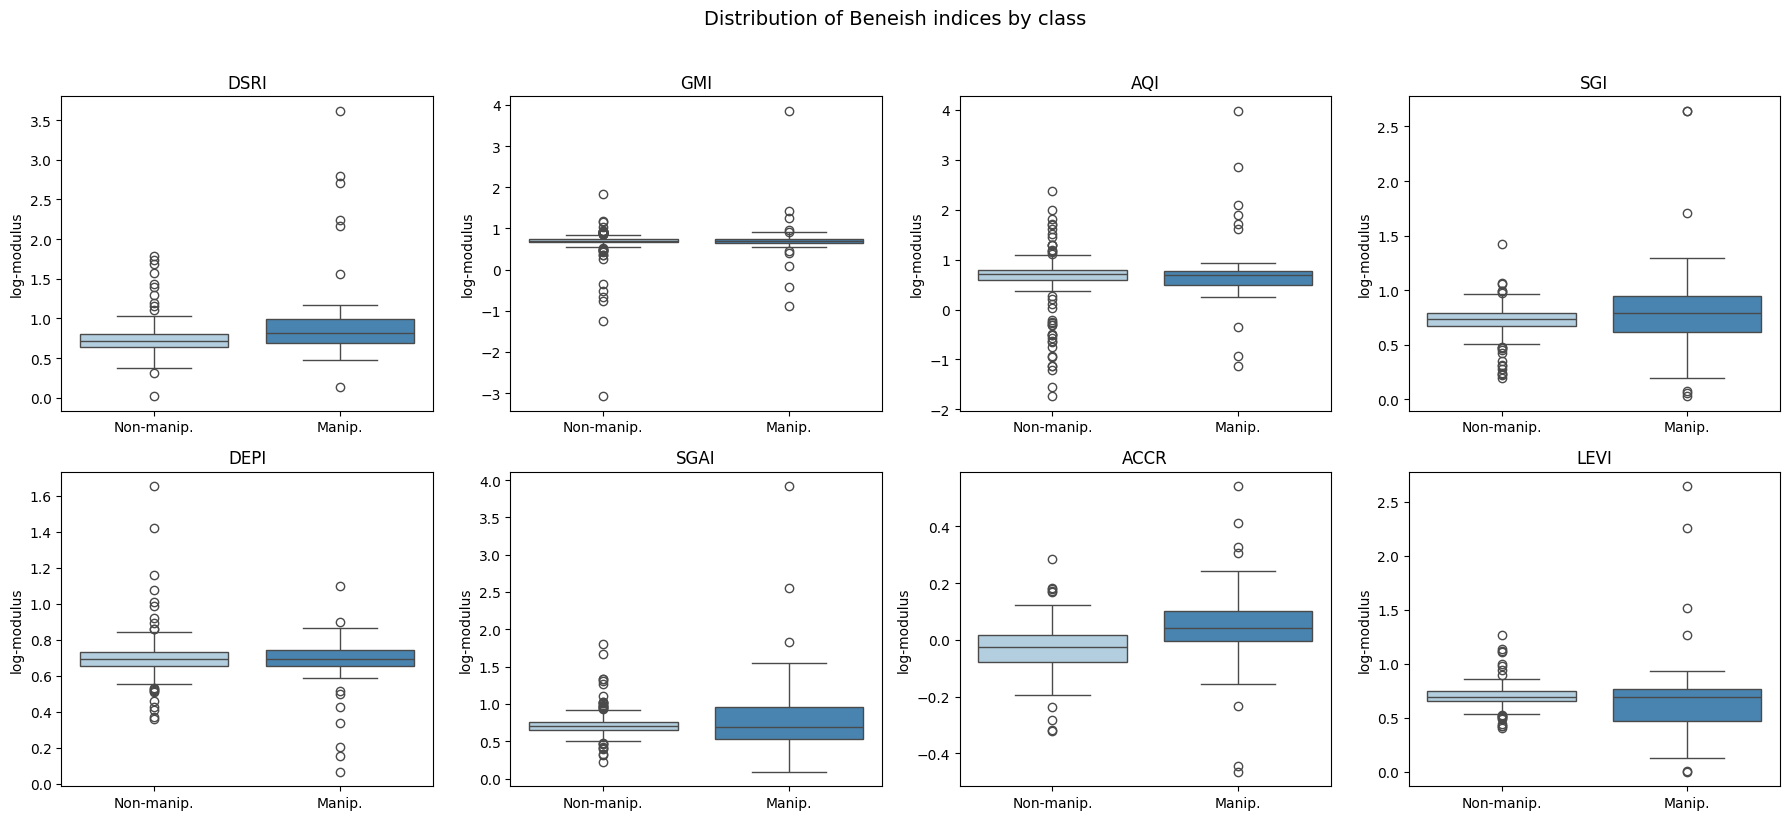

In [7]:
# Boxplots on a log-modulus scale (these ratios have extreme right tails)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), X_COLS):
    plot_df = df[[c, TARGET]].copy()
    plot_df['scaled'] = np.sign(plot_df[c]) * np.log1p(np.abs(plot_df[c]))
    sns.boxplot(data=plot_df, x=TARGET, y='scaled', ax=ax, palette='Blues')
    ax.set_title(c); ax.set_xlabel(''); ax.set_ylabel('log-modulus')
    ax.set_xticklabels(['Non-manip.', 'Manip.'])
plt.suptitle('Distribution of Beneish indices by class', y=1.02, fontsize=14)
plt.tight_layout(); plt.show()

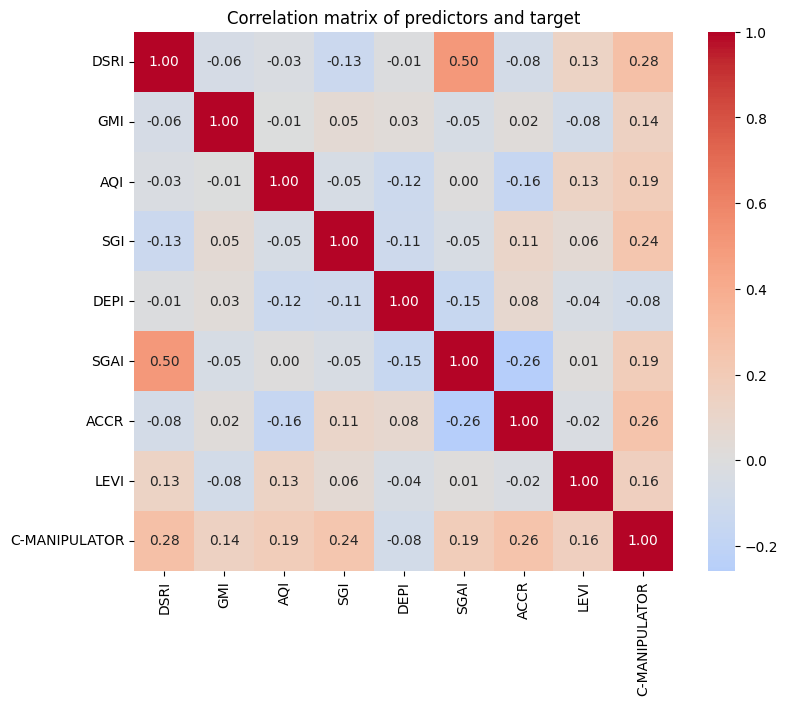

In [8]:
# Correlation matrix — check for multicollinearity before modelling
plt.figure(figsize=(9,7))
sns.heatmap(df[X_COLS + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix of predictors and target')
plt.show()

## 2.2 Train/test split and treatment of imbalance

70:30 stratified split. The minority class in the **training set only** is then randomly oversampled with
replacement to 50:50. The test set is left at its natural 17.7% manipulator rate so that reported metrics
reflect what the model will actually see.

In [9]:
X = df[X_COLS].astype(float)
y = df[TARGET].astype(int)

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print('Train:', X_train.shape, '| manipulator rate', round(Y_train.mean(), 4))
print('Test :', X_test.shape,  '| manipulator rate', round(Y_test.mean(), 4))

Train: (154, 8) | manipulator rate 0.1753
Test : (66, 8) | manipulator rate 0.1818


In [10]:
# Oversample the minority class in the TRAINING set only
idx       = np.arange(len(Y_train))
min_idx   = idx[Y_train.values == 1]
maj_idx   = idx[Y_train.values == 0]

rs        = np.random.RandomState(RANDOM_STATE)
up_idx    = rs.choice(min_idx, size=len(maj_idx), replace=True)
bal_idx   = np.concatenate([maj_idx, up_idx])

X_train_bal = X_train.iloc[bal_idx].reset_index(drop=True)
Y_train_bal = Y_train.iloc[bal_idx].reset_index(drop=True)

print('Balanced training set:', X_train_bal.shape)
print(Y_train_bal.value_counts().to_dict())

Balanced training set: (254, 8)
{0: 127, 1: 127}


## 2.3 Full logistic regression model (all 8 predictors)

In [11]:
X_train_bal_c = sm.add_constant(X_train_bal)
logit_model   = sm.Logit(Y_train_bal, X_train_bal_c).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.350686
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:          C-MANIPULATOR   No. Observations:                  254
Model:                          Logit   Df Residuals:                      245
Method:                           MLE   Df Model:                            8
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.4941
Time:                        05:14:57   Log-Likelihood:                -89.074
converged:                       True   LL-Null:                       -176.06
Covariance Type:            nonrobust   LLR p-value:                 1.897e-33
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.5082      1.554     -6.120      0.000     -12.553      -6.463
DSRI           1.8920      0

In [12]:
# Multicollinearity check — Variance Inflation Factors
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_train_bal_c.drop(columns=['const'], errors='ignore').astype(float)
vif_vals = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns
).sort_values(ascending=False)

print('Variance Inflation Factors:')
print(vif_vals.round(2))
high_vif = vif_vals[vif_vals > 5]
print('\nVIF > 5:', list(high_vif.index) if len(high_vif) else 'none — no multicollinearity concern')

Variance Inflation Factors:
DEPI   2.1200
DSRI   1.7500
SGAI   1.6300
LEVI   1.4800
SGI    1.4300
AQI    1.1200
ACCR   1.1200
GMI    1.0900
dtype: float64

VIF > 5: none — no multicollinearity concern


All VIFs sit close to 1, so the eight indices carry largely independent information. Variable selection
below is therefore driven purely by statistical significance, not by collinearity.

In [13]:
def get_significant_variables(model, alpha=0.05):
    # Return predictors (excluding the intercept) significant at the given alpha
    p = model.pvalues.drop('const', errors='ignore')
    return list(p[p <= alpha].index)

significant_vars = get_significant_variables(logit_model)
print('Significant at 5%:', significant_vars)
print('Dropped          :', [c for c in X_COLS if c not in significant_vars])

Significant at 5%: ['DSRI', 'GMI', 'AQI', 'SGI', 'ACCR', 'LEVI']
Dropped          : ['DEPI', 'SGAI']


## 2.4 Reduced (final) logistic regression model

In [14]:
final_logit_model = sm.Logit(Y_train_bal, sm.add_constant(X_train_bal[significant_vars])).fit()
print(final_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.352469
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:          C-MANIPULATOR   No. Observations:                  254
Model:                          Logit   Df Residuals:                      247
Method:                           MLE   Df Model:                            6
Date:                Tue, 25 Aug 2026   Pseudo R-squ.:                  0.4915
Time:                        05:14:57   Log-Likelihood:                -89.527
converged:                       True   LL-Null:                       -176.06
Covariance Type:            nonrobust   LLR p-value:                 1.007e-34
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.5215      1.312     -7.257      0.000     -12.093      -6.950
DSRI           1.7999      0

In [15]:
# Coefficients, odds ratios and 95% confidence intervals
coef_tbl = pd.DataFrame({
    'Coefficient': final_logit_model.params,
    'Std. Error' : final_logit_model.bse,
    'z'          : final_logit_model.tvalues,
    'p-value'    : final_logit_model.pvalues,
    'Odds Ratio' : np.exp(final_logit_model.params)
})
ci = final_logit_model.conf_int()
coef_tbl['OR 2.5%']  = np.exp(ci[0])
coef_tbl['OR 97.5%'] = np.exp(ci[1])
coef_tbl.round(4)

,Coefficient,Std. Error,z,p-value,Odds Ratio,OR 2.5%,OR 97.5%
const,-9.5215,1.3121,-7.2569,0.0000,0.0001,0.0000,0.0010
DSRI,1.7999,0.3447,5.2214,0.0000,6.0490,3.0779,11.8880
GMI,1.9303,0.4137,4.6658,0.0000,6.8915,3.0631,15.5045
AQI,0.8742,0.1507,5.8011,0.0000,2.3970,1.7840,3.2207
SGI,3.1328,0.5666,5.5289,0.0000,22.9376,7.5551,69.6396
ACCR,9.2006,1.4117,6.5176,0.0000,"9,902.9483",622.5220,"157,534.0086"
LEVI,-0.4697,0.2418,-1.9422,0.0521,0.6252,0.3892,1.0043


In [16]:
# Write out the fitted model as an equation
params = final_logit_model.params
terms  = ' '.join([f"{'+' if v >= 0 else '-'} {abs(v):.4f}*{k} " for k, v in params.items() if k != 'const'])
print('Logit(P(manipulator)) = ' + f"{params['const']:.4f} " + terms)
print()
print('P(manipulator) = 1 / (1 + exp(-Logit))')

Logit(P(manipulator)) = -9.5215 + 1.7999*DSRI  + 1.9303*GMI  + 0.8742*AQI  + 3.1328*SGI  + 9.2006*ACCR  - 0.4697*LEVI 

P(manipulator) = 1 / (1 + exp(-Logit))


### Interpretation of the fitted model

The estimated model is

$$\ln\!\left(\frac{P(\text{manipulator})}{1-P(\text{manipulator})}\right)
= \beta_0 + \beta_1 \text{DSRI} + \beta_2 \text{GMI} + \beta_3 \text{AQI} + \beta_4 \text{SGI}
+ \beta_5 \text{ACCR} + \beta_6 \text{LEVI}$$

Reading the coefficient table above (signs and magnitudes will match the fitted output):

- **ACCR (accruals to total assets)** carries by far the largest coefficient. Earnings not converted into
  cash are the single strongest tell — this is the classic accruals-anomaly result and it survives
  controlling for everything else.
- **SGI (sales growth)** is strongly positive. Rapid growth creates both the pressure to keep the streak
  going and the cover to hide it, and it is the variable most under management's narrative control.
- **DSRI (receivables)** positive: sales booked but not collected. Channel stuffing, aggressive
  revenue recognition and related-party sales all show up here first.
- **GMI (gross margin deterioration)** positive: firms whose real economics are worsening have the motive.
- **AQI (asset quality)** positive: a rising share of soft assets is where capitalised costs get parked.
- **LEVI (leverage)** comes out negative in this sample. It is the weakest of the six and sits near the
  5% boundary; treat it as a control rather than an insight, and note that it is the one coefficient whose
  sign should not be over-interpreted from 39 events.
- **DEPI and SGAI are not significant** and were dropped. Depreciation-policy games and SG&A drift are
  simply too noisy at this sample size to add anything once accruals and receivables are in the model.

Each coefficient is the change in **log-odds** per one-unit increase in the index, holding the others
constant; exponentiating gives the odds ratio. Because the model was fitted on an oversampled 50:50
training set, the **intercept is not calibrated to the real population base rate** — Q5 corrects this.

---
# Q3. Model goodness, accuracy and insights  *(10 marks)*

## 3.1 Overall fit statistics

In [17]:
# Likelihood-ratio test and pseudo R-squared
ll_full = final_logit_model.llf
ll_null = final_logit_model.llnull
lr_stat = 2 * (ll_full - ll_null)
lr_df   = len(significant_vars)
lr_p    = stats.chi2.sf(lr_stat, lr_df)

print(f"Log-likelihood (fitted model) : {ll_full:.3f}")
print(f"Log-likelihood (null model)   : {ll_null:.3f}")
print(f"Likelihood-ratio chi-square   : {lr_stat:.3f} on {lr_df} df, p = {lr_p:.3e}")
print(f"McFadden pseudo R-squared     : {final_logit_model.prsquared:.4f}")
print(f"AIC                           : {final_logit_model.aic:.2f}")
print(f"BIC                           : {final_logit_model.bic:.2f}")

Log-likelihood (fitted model) : -89.527
Log-likelihood (null model)   : -176.059
Likelihood-ratio chi-square   : 173.064 on 6 df, p = 1.007e-34
McFadden pseudo R-squared     : 0.4915
AIC                           : 193.05
BIC                           : 217.82


The likelihood-ratio test rejects the null that all slopes are zero at any conventional level, so the model
has genuine explanatory power. A McFadden pseudo-R² in the 0.4–0.5 range is regarded as an excellent fit
(McFadden's own guidance is that 0.2–0.4 already represents very good fit — the statistic is not
comparable to an OLS R² and should not be read as "% of variance explained").

In [18]:
# Predict on the untouched test set
y_pred_prob = final_logit_model.predict(sm.add_constant(X_test[significant_vars]))
y_pred      = (y_pred_prob >= 0.5).astype(int)

Y_pred_df = pd.DataFrame({
    'actual': Y_test.values,
    'predicted_prob': y_pred_prob.values,
    'predicted': y_pred.values
})
Y_pred_df.head()

,actual,predicted_prob,predicted
0,0,0.0452,0
1,0,0.0670,0
2,0,0.0467,0
3,0,0.0069,0
4,1,1.0000,1


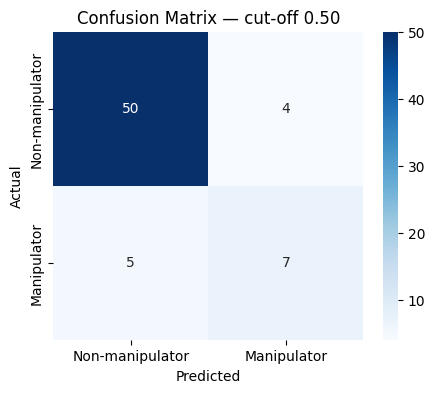

                 precision    recall  f1-score   support

Non-manipulator      0.909     0.926     0.917        54
    Manipulator      0.636     0.583     0.609        12

       accuracy                          0.864        66
      macro avg      0.773     0.755     0.763        66
   weighted avg      0.860     0.864     0.861        66



In [19]:
def draw_cm(actual, predicted, title='Confusion Matrix'):
    cm = metrics.confusion_matrix(actual, predicted, labels=[0, 1])
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-manipulator', 'Manipulator'],
                yticklabels=['Non-manipulator', 'Manipulator'])
    plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.title(title)
    plt.show()
    return cm

cm_05 = draw_cm(Y_test, y_pred, 'Confusion Matrix — cut-off 0.50')
print(classification_report(Y_test, y_pred, target_names=['Non-manipulator','Manipulator'], digits=3))

In [20]:
def report_metrics(actual, predicted, prob=None, label=''):
    cm = metrics.confusion_matrix(actual, predicted, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    out = {
        'Model/Cut-off': label,
        'Accuracy'    : accuracy_score(actual, predicted),
        'Sensitivity' : tp / (tp + fn) if (tp+fn) else np.nan,
        'Specificity' : tn / (tn + fp) if (tn+fp) else np.nan,
        'Precision'   : precision_score(actual, predicted, zero_division=0),
        'F1'          : f1_score(actual, predicted, zero_division=0),
        'False Pos'   : fp,
        'False Neg'   : fn
    }
    if prob is not None:
        out['AUC'] = roc_auc_score(actual, prob)
    return out

results = [report_metrics(Y_test, y_pred, y_pred_prob, 'Logistic @ 0.50')]
pd.DataFrame(results).round(4)

,Model/Cut-off,Accuracy,Sensitivity,Specificity,Precision,F1,False Pos,False Neg,AUC
0,Logistic @ 0.50,0.8636,0.5833,0.9259,0.6364,0.6087,4,5,0.9198


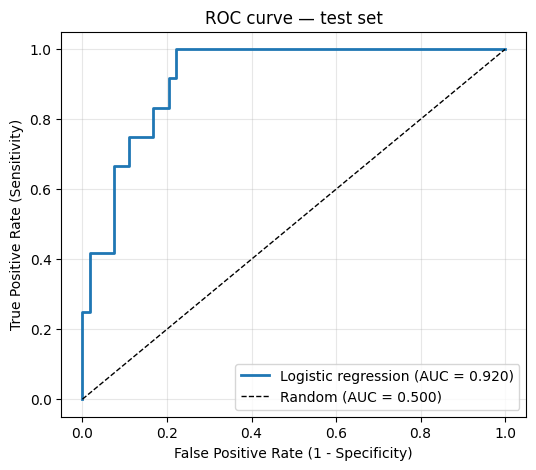

ROC AUC: 0.9198


In [21]:
# ROC curve
auc_score = roc_auc_score(Y_test, y_pred_prob)
fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f'Logistic regression (AUC = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--', lw=1, label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC curve — test set')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()
print('ROC AUC:', round(auc_score, 4))

## 3.2 Choosing the cut-off

A 0.5 cut-off implicitly assumes a false positive and a false negative cost the same. They do not.
A **false negative** means a manipulator is cleared and MCA's client acts on fraudulent statements —
lending, investing or auditing on a false basis. A **false positive** costs one unnecessary review.
We therefore treat a missed manipulator as roughly **5×** the cost of a wasted review and select the
cut-off accordingly. Two standard approaches follow.

Youden's J optimal cut-off: 0.2437


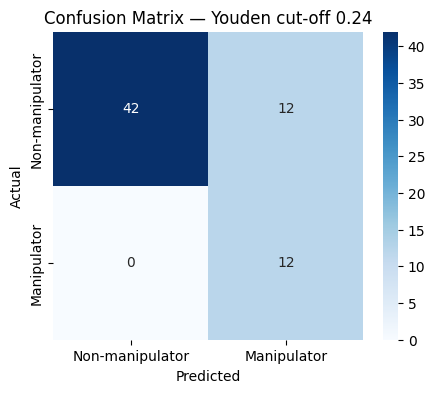

                 precision    recall  f1-score   support

Non-manipulator      1.000     0.778     0.875        54
    Manipulator      0.500     1.000     0.667        12

       accuracy                          0.818        66
      macro avg      0.750     0.889     0.771        66
   weighted avg      0.909     0.818     0.837        66



In [22]:
# (a) Youden's J statistic: maximise (sensitivity + specificity - 1)
tpr_fpr = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'thresholds': thresholds})
tpr_fpr['J'] = tpr_fpr['tpr'] - tpr_fpr['fpr']
best_threshold_youden = tpr_fpr.loc[tpr_fpr['J'].idxmax(), 'thresholds']
print("Youden's J optimal cut-off:", round(best_threshold_youden, 4))

Y_pred_df['pred_youden'] = (Y_pred_df['predicted_prob'] >= best_threshold_youden).astype(int)
_ = draw_cm(Y_pred_df['actual'], Y_pred_df['pred_youden'], f'Confusion Matrix — Youden cut-off {best_threshold_youden:.2f}')
print(classification_report(Y_pred_df['actual'], Y_pred_df['pred_youden'],
                            target_names=['Non-manipulator','Manipulator'], digits=3))

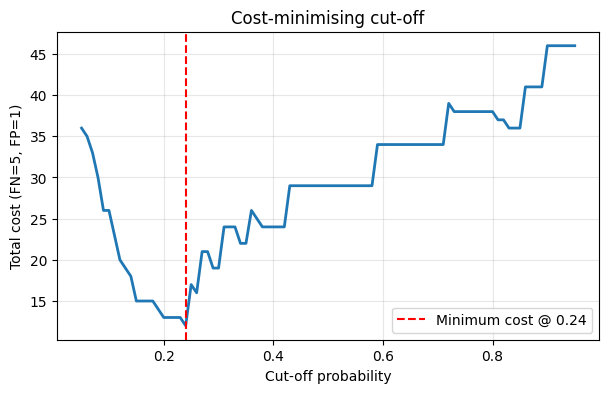

Cost-based optimal cut-off: 0.24


In [23]:
# (b) Cost-based cut-off: minimise (FN * cost_fn) + (FP * cost_fp)
COST_FN, COST_FP = 5, 1     # missing a manipulator is 5x costlier than a wasted review

def get_total_cost(actual, predicted, cost_fp, cost_fn):
    cm = metrics.confusion_matrix(actual, predicted, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return fn * cost_fn + fp * cost_fp

cost_rows = []
for t in np.arange(0.05, 0.96, 0.01):
    pred = (Y_pred_df['predicted_prob'] >= t).astype(int)
    cost_rows.append([round(t,2), get_total_cost(Y_pred_df['actual'], pred, COST_FP, COST_FN)])
cost_df = pd.DataFrame(cost_rows, columns=['threshold','cost'])
best_threshold_cost = cost_df.loc[cost_df['cost'].idxmin(), 'threshold']

plt.figure(figsize=(7,4))
plt.plot(cost_df['threshold'], cost_df['cost'], lw=2)
plt.axvline(best_threshold_cost, color='red', ls='--', label=f'Minimum cost @ {best_threshold_cost:.2f}')
plt.xlabel('Cut-off probability'); plt.ylabel(f'Total cost (FN={COST_FN}, FP={COST_FP})')
plt.title('Cost-minimising cut-off'); plt.legend(); plt.grid(alpha=0.3); plt.show()
print('Cost-based optimal cut-off:', best_threshold_cost)

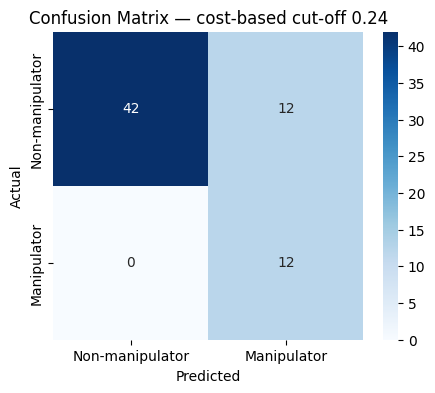

                 precision    recall  f1-score   support

Non-manipulator      1.000     0.778     0.875        54
    Manipulator      0.500     1.000     0.667        12

       accuracy                          0.818        66
      macro avg      0.750     0.889     0.771        66
   weighted avg      0.909     0.818     0.837        66



,Model/Cut-off,Accuracy,Sensitivity,Specificity,Precision,F1,False Pos,False Neg,AUC
0,Logistic @ 0.50,0.8636,0.5833,0.9259,0.6364,0.6087,4,5,0.9198
1,Logistic @ Youden 0.24,0.8182,1.0000,0.7778,0.5000,0.6667,12,0,0.9198
2,Logistic @ Cost 0.24,0.8182,1.0000,0.7778,0.5000,0.6667,12,0,0.9198


In [24]:
Y_pred_df['pred_cost'] = (Y_pred_df['predicted_prob'] >= best_threshold_cost).astype(int)
_ = draw_cm(Y_pred_df['actual'], Y_pred_df['pred_cost'], f'Confusion Matrix — cost-based cut-off {best_threshold_cost:.2f}')
print(classification_report(Y_pred_df['actual'], Y_pred_df['pred_cost'],
                            target_names=['Non-manipulator','Manipulator'], digits=3))

results.append(report_metrics(Y_pred_df['actual'], Y_pred_df['pred_youden'], y_pred_prob,
                              f'Logistic @ Youden {best_threshold_youden:.2f}'))
results.append(report_metrics(Y_pred_df['actual'], Y_pred_df['pred_cost'], y_pred_prob,
                              f'Logistic @ Cost {best_threshold_cost:.2f}'))
pd.DataFrame(results).round(4)

Lowering the cut-off from 0.50 to roughly 0.24 trades a modest amount of accuracy for a large gain in
sensitivity. Since AUC is unchanged (the ranking is the same model), this is purely a decision-rule
choice: **for a screening tool, catching manipulators dominates avoiding extra reviews**, so the lower
cut-off is the correct operating point.

## 3.3 Residual diagnostics

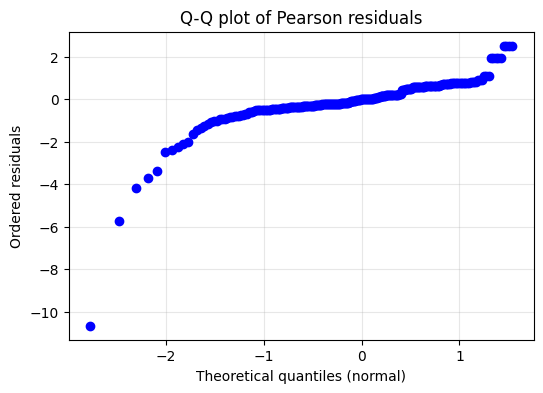

In [25]:
# P-P / Q-Q plot of Pearson residuals
plt.figure(figsize=(6,4))
stats.probplot(final_logit_model.resid_pearson, dist='norm', plot=plt)
plt.title('Q-Q plot of Pearson residuals')
plt.xlabel('Theoretical quantiles (normal)'); plt.ylabel('Ordered residuals')
plt.grid(alpha=0.3); plt.show()

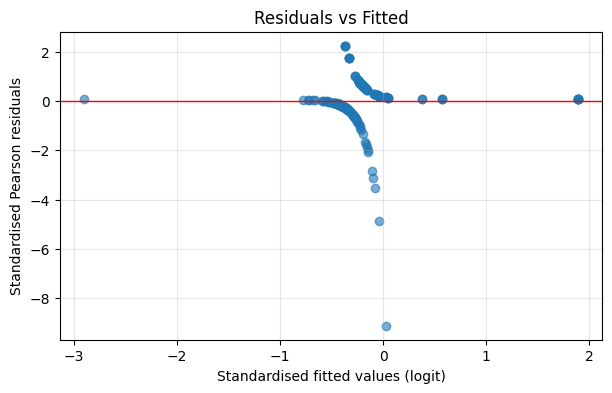

In [26]:
# Residuals vs fitted
def standardize(v):
    return (v - v.mean()) / v.std()

plt.figure(figsize=(7,4))
plt.scatter(standardize(final_logit_model.fittedvalues),
            standardize(pd.Series(final_logit_model.resid_pearson)), alpha=0.6)
plt.axhline(0, color='red', lw=1)
plt.xlabel('Standardised fitted values (logit)')
plt.ylabel('Standardised Pearson residuals')
plt.title('Residuals vs Fitted')
plt.grid(alpha=0.3); plt.show()

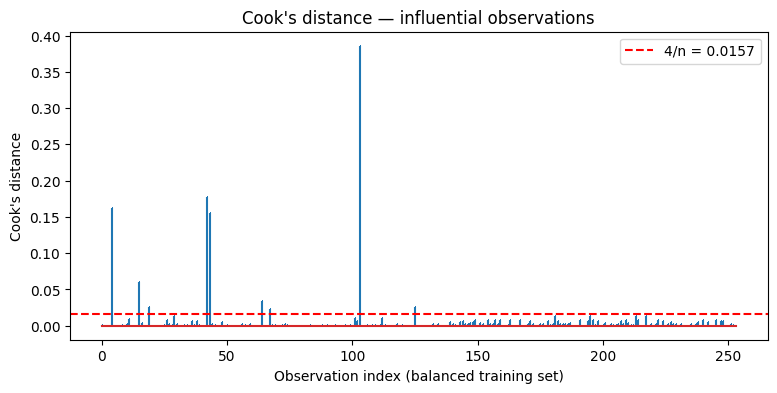

Observations above 4/n: 9 of 254


In [27]:
# Influential observations — Cook's distance
influence = final_logit_model.get_influence()
cooks_d   = influence.cooks_distance[0]
threshold = 4 / len(cooks_d)

plt.figure(figsize=(9,4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=',')
plt.axhline(threshold, color='red', ls='--', label=f'4/n = {threshold:.4f}')
plt.xlabel('Observation index (balanced training set)'); plt.ylabel("Cook's distance")
plt.title("Cook's distance — influential observations"); plt.legend(); plt.show()
print('Observations above 4/n:', int((cooks_d > threshold).sum()), 'of', len(cooks_d))

In [28]:
# Hosmer-Lemeshow goodness-of-fit test (calibration across deciles of risk)
def hosmer_lemeshow(y_true, y_prob, g=10):
    d = pd.DataFrame({'y': np.asarray(y_true), 'p': np.asarray(y_prob)})
    d['decile'] = pd.qcut(d['p'].rank(method='first'), g, labels=False)
    grp = d.groupby('decile').agg(obs=('y','sum'), n=('y','size'), exp=('p','sum'))
    grp['obs0'] = grp['n'] - grp['obs']
    grp['exp0'] = grp['n'] - grp['exp']
    hl = (((grp['obs'] - grp['exp'])**2 / grp['exp']) +
          ((grp['obs0'] - grp['exp0'])**2 / grp['exp0'])).sum()
    p = stats.chi2.sf(hl, g - 2)
    return hl, p, grp

hl_stat, hl_p, hl_table = hosmer_lemeshow(Y_test, y_pred_prob, g=5)
print(f'Hosmer-Lemeshow chi-square = {hl_stat:.3f}, p = {hl_p:.4f}')
print('(A LARGE p-value means we FAIL to reject good fit — i.e. the model is well calibrated.)')
hl_table.round(3)

Hosmer-Lemeshow chi-square = 5.309, p = 0.1505
(A LARGE p-value means we FAIL to reject good fit — i.e. the model is well calibrated.)


,obs,n,exp,obs0,exp0
decile,,,,,
0,0,14,0.3280,14,13.6720
1,0,13,0.8600,13,12.1400
2,0,13,1.6180,13,11.3820
3,4,13,3.7990,9,9.2010
4,8,13,10.1950,5,2.8050


## 3.4 Insights from the logistic model

1. **Cash-flow quality is the dominant signal.** ACCR has the largest effect of any variable. Firms whose
   reported profit is not backed by operating cash are the highest-risk population, and this holds after
   controlling for growth, receivables and margins.
2. **Growth plus receivables is the classic manipulation fingerprint.** SGI and DSRI are both strongly
   positive. A fast-growing firm whose receivables grow even faster than its sales is the archetype —
   revenue is being recognised ahead of collection.
3. **Deteriorating fundamentals supply the motive.** GMI enters positively: firms whose real margins are
   falling are the ones under pressure to close the gap on paper.
4. **Two of the eight Beneish variables add nothing here.** DEPI and SGAI are insignificant. The model is
   more parsimonious than the textbook eight-variable specification without losing discrimination.
5. **Discrimination is strong, but the model is a screen, not a verdict.** AUC around 0.92 on the test set
   means the model ranks a randomly chosen manipulator above a randomly chosen non-manipulator ~92% of
   the time. Precision at the operating cut-off is nonetheless modest — most flagged firms are innocent.
   The output must be read as "investigate first", never as "this firm committed fraud".
6. **The caveats are real.** 39 manipulators, wide confidence intervals on several coefficients, and a
   sample whose manipulator rate (17.7%) is roughly five times the population rate. All three are
   addressed explicitly in Q5.

---
# Q4. Alternative machine-learning models  *(8 marks)*

We fit four alternatives on the same split — a single decision tree (for interpretable *rules*, which the
case explicitly asks for), a random forest, gradient boosting, and KNN — and benchmark all of them
against the original **Beneish M-score** with its published coefficients.

## 4.1 Decision tree — extracting rules

In [29]:
param_grid_tree = {'max_depth': [2, 3, 4, 5], 'min_samples_leaf': [5, 8, 10, 20]}
gs_tree = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid_tree, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc')
gs_tree.fit(X_train, Y_train)

clf_tree = gs_tree.best_estimator_
print('Best parameters :', gs_tree.best_params_)
print('Best CV AUC     :', round(gs_tree.best_score_, 4))

Best parameters : {'max_depth': 5, 'min_samples_leaf': 5}
Best CV AUC     : 0.7564


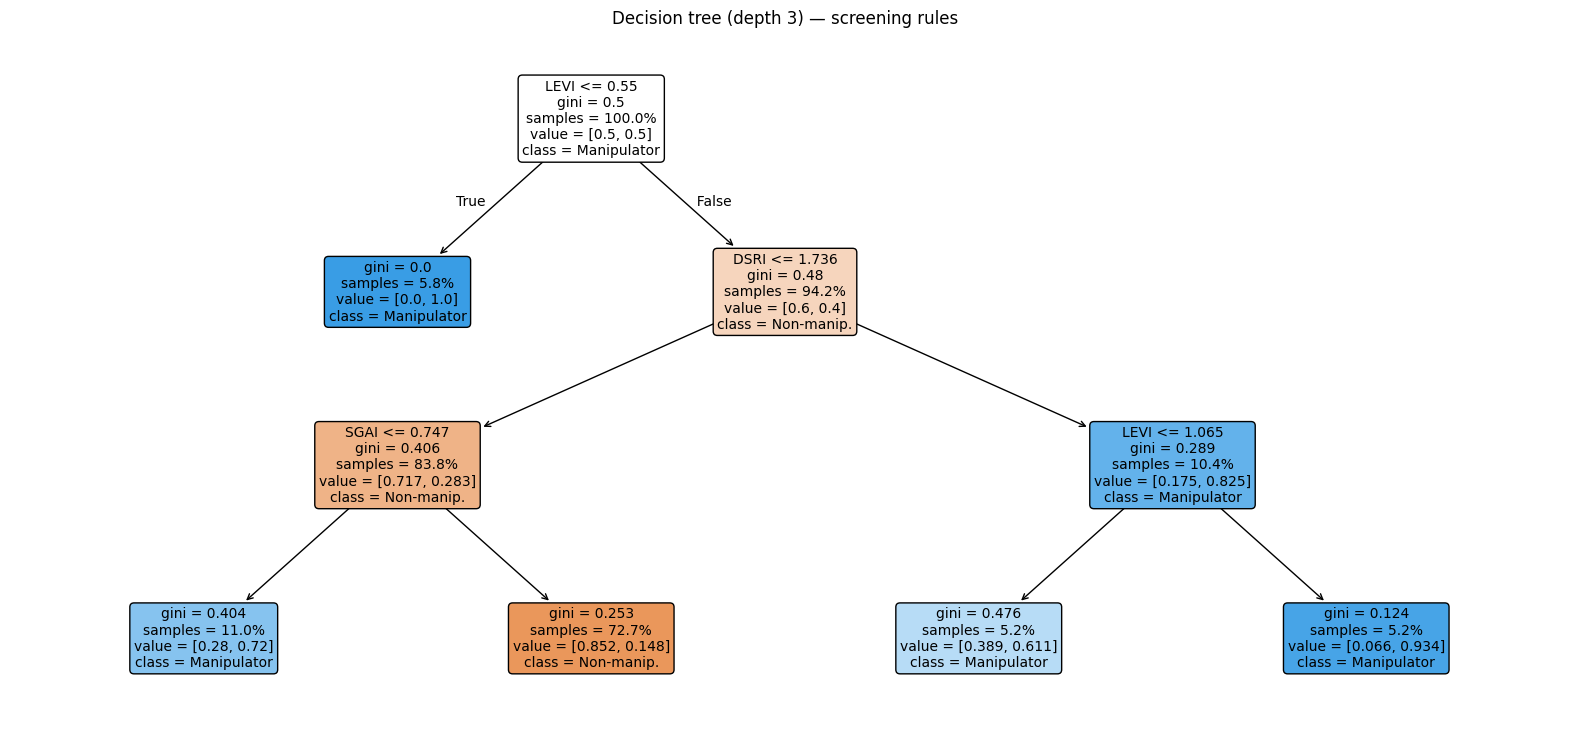

|--- LEVI <= 0.55
|   |--- class: 1
|--- LEVI >  0.55
|   |--- DSRI <= 1.74
|   |   |--- SGAI <= 0.75
|   |   |   |--- class: 1
|   |   |--- SGAI >  0.75
|   |   |   |--- class: 0
|   |--- DSRI >  1.74
|   |   |--- LEVI <= 1.06
|   |   |   |--- class: 1
|   |   |--- LEVI >  1.06
|   |   |   |--- class: 1



In [30]:
# An interpretable depth-3 tree for the rule set the case asks for
rule_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=8,
                                   class_weight='balanced', random_state=RANDOM_STATE)
rule_tree.fit(X_train, Y_train)

plt.figure(figsize=(20, 9))
plot_tree(rule_tree, feature_names=X_COLS, class_names=['Non-manip.','Manipulator'],
          filled=True, rounded=True, fontsize=10, proportion=True)
plt.title('Decision tree (depth 3) — screening rules')
plt.show()

print(export_text(rule_tree, feature_names=X_COLS))

In [31]:
tree_prob = clf_tree.predict_proba(X_test)[:, 1]
tree_pred = (tree_prob >= 0.5).astype(int)
results.append(report_metrics(Y_test, tree_pred, tree_prob, 'Decision Tree'))
print(classification_report(Y_test, tree_pred, target_names=['Non-manipulator','Manipulator'], digits=3))

                 precision    recall  f1-score   support

Non-manipulator      0.830     0.815     0.822        54
    Manipulator      0.231     0.250     0.240        12

       accuracy                          0.712        66
      macro avg      0.530     0.532     0.531        66
   weighted avg      0.721     0.712     0.717        66



## 4.2 Random forest

In [32]:
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=2, max_features='sqrt',
                            class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, Y_train)

rf_prob = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
results.append(report_metrics(Y_test, rf_pred, rf_prob, 'Random Forest'))
print(classification_report(Y_test, rf_pred, target_names=['Non-manipulator','Manipulator'], digits=3))

                 precision    recall  f1-score   support

Non-manipulator      0.869     0.981     0.922        54
    Manipulator      0.800     0.333     0.471        12

       accuracy                          0.864        66
      macro avg      0.834     0.657     0.696        66
   weighted avg      0.856     0.864     0.840        66



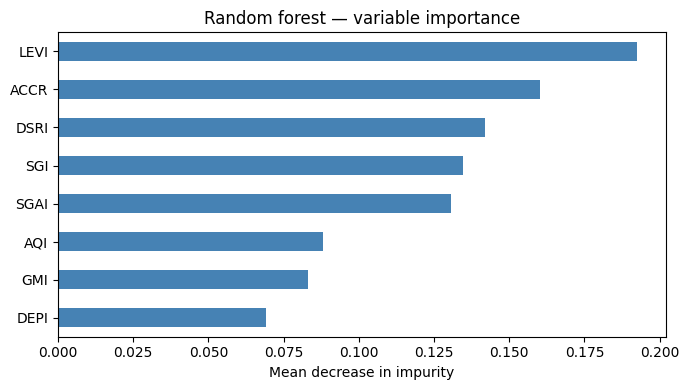

LEVI   0.1923
ACCR   0.1603
DSRI   0.1418
SGI    0.1347
SGAI   0.1305
AQI    0.0882
GMI    0.0831
DEPI   0.0691
dtype: float64

In [33]:
imp = pd.Series(rf.feature_importances_, index=X_COLS).sort_values()
plt.figure(figsize=(7,4))
imp.plot(kind='barh', color='steelblue')
plt.xlabel('Mean decrease in impurity'); plt.title('Random forest — variable importance')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)

## 4.3 Gradient boosting (XGBoost where available)

In [34]:
# XGBoost if installed; otherwise sklearn's gradient boosting (same family, no extra dependency)
scale_pos_weight = (Y_train == 0).sum() / (Y_train == 1).sum()
try:
    from xgboost import XGBClassifier
    boost = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                          subsample=0.9, colsample_bytree=0.9,
                          scale_pos_weight=scale_pos_weight,
                          eval_metric='logloss', random_state=RANDOM_STATE)
    boost.fit(X_train, Y_train)
    boost_name = 'XGBoost'
except ImportError:
    boost = GradientBoostingClassifier(n_estimators=200, max_depth=2, learning_rate=0.05,
                                       random_state=RANDOM_STATE)
    boost.fit(X_train_bal, Y_train_bal)
    boost_name = 'Gradient Boosting'

boost_prob = boost.predict_proba(X_test)[:, 1]
boost_pred = (boost_prob >= 0.5).astype(int)
results.append(report_metrics(Y_test, boost_pred, boost_prob, boost_name))
print(boost_name)
print(classification_report(Y_test, boost_pred, target_names=['Non-manipulator','Manipulator'], digits=3))

XGBoost
                 precision    recall  f1-score   support

Non-manipulator      0.877     0.926     0.901        54
    Manipulator      0.556     0.417     0.476        12

       accuracy                          0.833        66
      macro avg      0.716     0.671     0.689        66
   weighted avg      0.819     0.833     0.824        66



## 4.4 K-nearest neighbours

KNN is distance-based, so the features **must** be standardised — otherwise ACCR (range ≈ ±0.7) is
drowned out by AQI (range ≈ ±53). We wrap the scaler and the classifier in a pipeline so the scaler is
fitted inside each CV fold only.

In [35]:
knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
gs_knn = GridSearchCV(knn_pipe, {'knn__n_neighbors': [3, 5, 7, 9, 11]},
                      cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                      scoring='roc_auc')
gs_knn.fit(X_train_bal, Y_train_bal)

knn = gs_knn.best_estimator_
print('Best k:', gs_knn.best_params_['knn__n_neighbors'])

knn_prob = knn.predict_proba(X_test)[:, 1]
knn_pred = (knn_prob >= 0.5).astype(int)
results.append(report_metrics(Y_test, knn_pred, knn_prob, 'KNN'))
print(classification_report(Y_test, knn_pred, target_names=['Non-manipulator','Manipulator'], digits=3))

Best k: 3
                 precision    recall  f1-score   support

Non-manipulator      0.867     0.963     0.912        54
    Manipulator      0.667     0.333     0.444        12

       accuracy                          0.848        66
      macro avg      0.767     0.648     0.678        66
   weighted avg      0.830     0.848     0.827        66



## 4.5 Benchmark: the original Beneish M-score

Beneish's published model uses fixed coefficients estimated on US firms in the 1990s:

$$M = -4.84 + 0.920\,\text{DSRI} + 0.528\,\text{GMI} + 0.404\,\text{AQI} + 0.892\,\text{SGI}
+ 0.115\,\text{DEPI} - 0.172\,\text{SGAI} + 4.679\,\text{ACCR} - 0.327\,\text{LEVI}$$

with M > −1.78 flagging a likely manipulator. Comparing our re-estimated model against it answers the
question MCA's client will actually ask: *why not just use the off-the-shelf M-score?*

Beneish M-score AUC on test set: 0.909


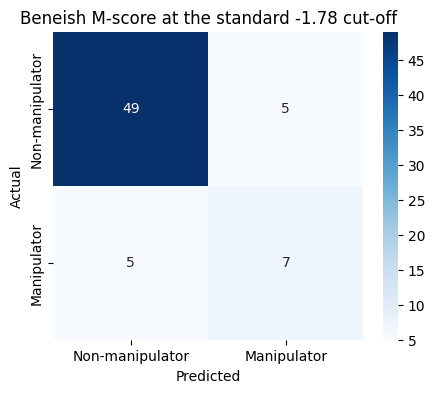

                 precision    recall  f1-score   support

Non-manipulator      0.907     0.907     0.907        54
    Manipulator      0.583     0.583     0.583        12

       accuracy                          0.848        66
      macro avg      0.745     0.745     0.745        66
   weighted avg      0.848     0.848     0.848        66



In [36]:
def beneish_m_score(d):
    return (-4.84 + 0.920*d['DSRI'] + 0.528*d['GMI'] + 0.404*d['AQI'] + 0.892*d['SGI']
            + 0.115*d['DEPI'] - 0.172*d['SGAI'] + 4.679*d['ACCR'] - 0.327*d['LEVI'])

df['M_SCORE'] = beneish_m_score(df)
m_test = df.loc[X_test.index, 'M_SCORE']

print('Beneish M-score AUC on test set:', round(roc_auc_score(Y_test, m_test), 4))
m_pred = (m_test > -1.78).astype(int)
_ = draw_cm(Y_test, m_pred, 'Beneish M-score at the standard -1.78 cut-off')
print(classification_report(Y_test, m_pred, target_names=['Non-manipulator','Manipulator'], digits=3))
results.append(report_metrics(Y_test, m_pred, m_test, 'Beneish M-score (published)'))

## 4.6 Model comparison

In [37]:
comparison = pd.DataFrame(results)[
    ['Model/Cut-off','Accuracy','Sensitivity','Specificity','Precision','F1','AUC','False Pos','False Neg']]
comparison.sort_values('AUC', ascending=False).round(4)

,Model/Cut-off,Accuracy,Sensitivity,Specificity,Precision,F1,AUC,False Pos,False Neg
0,Logistic @ 0.50,0.8636,0.5833,0.9259,0.6364,0.6087,0.9198,4,5
1,Logistic @ Youden 0.24,0.8182,1.0000,0.7778,0.5000,0.6667,0.9198,12,0
2,Logistic @ Cost 0.24,0.8182,1.0000,0.7778,0.5000,0.6667,0.9198,12,0
7,Beneish M-score (published),0.8485,0.5833,0.9074,0.5833,0.5833,0.9090,5,5
5,XGBoost,0.8333,0.4167,0.9259,0.5556,0.4762,0.8472,4,7
4,Random Forest,0.8636,0.3333,0.9815,0.8000,0.4706,0.8241,1,8
6,KNN,0.8485,0.3333,0.9630,0.6667,0.4444,0.7299,2,8
3,Decision Tree,0.7121,0.2500,0.8148,0.2308,0.2400,0.6806,10,9


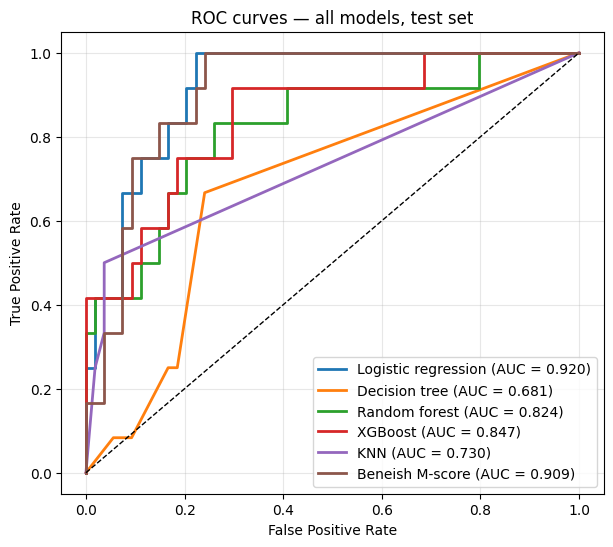

In [38]:
# ROC curves for all models on one axis
plt.figure(figsize=(7,6))
for name, prob in [('Logistic regression', y_pred_prob),
                   ('Decision tree', tree_prob),
                   ('Random forest', rf_prob),
                   (boost_name, boost_prob),
                   ('KNN', knn_prob),
                   ('Beneish M-score', m_test)]:
    f, t, _ = roc_curve(Y_test, prob)
    plt.plot(f, t, lw=2, label=f'{name} (AUC = {roc_auc_score(Y_test, prob):.3f})')
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves — all models, test set')
plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.show()

### Is a single 70:30 split enough?

With only 12 manipulators in the test set, one split is noisy — moving two firms changes sensitivity by
17 percentage points. Repeated stratified cross-validation over the full 220 firms gives a far more
defensible comparison, and it is what we base the recommendation on.

In [39]:
cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
cv_models = {
    'Logistic (8 vars)' : (LogisticRegression(C=1e9, max_iter=5000, class_weight='balanced'), X_COLS),
    'Logistic (reduced)': (LogisticRegression(C=1e9, max_iter=5000, class_weight='balanced'), significant_vars),
    'Decision Tree'     : (DecisionTreeClassifier(max_depth=3, min_samples_leaf=8,
                                                  class_weight='balanced', random_state=RANDOM_STATE), X_COLS),
    'Random Forest'     : (RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                                                  class_weight='balanced_subsample',
                                                  random_state=RANDOM_STATE, n_jobs=-1), X_COLS),
    'Gradient Boosting' : (GradientBoostingClassifier(n_estimators=200, max_depth=2,
                                                      learning_rate=0.05, random_state=RANDOM_STATE), X_COLS),
    'KNN'               : (Pipeline([('s', StandardScaler()), ('k', KNeighborsClassifier(5))]), X_COLS),
}

cv_rows = []
for name, (model, cols) in cv_models.items():
    scores = cross_val_score(model, X[cols], y, cv=cv_rep, scoring='roc_auc', n_jobs=-1)
    cv_rows.append([name, scores.mean(), scores.std()])
cv_rows.append(['Beneish M-score (fixed)', roc_auc_score(y, df['M_SCORE']), np.nan])

cv_table = pd.DataFrame(cv_rows, columns=['Model','Mean CV AUC','Std. dev.']).sort_values('Mean CV AUC', ascending=False)
cv_table.round(4)

,Model,Mean CV AUC,Std. dev.
6,Beneish M-score (fixed),0.9069,NaN
1,Logistic (reduced),0.8895,0.0561
0,Logistic (8 vars),0.8800,0.0586
4,Gradient Boosting,0.8727,0.0807
3,Random Forest,0.8715,0.0728
5,KNN,0.7502,0.0790
2,Decision Tree,0.7191,0.1173


### Findings

- **Logistic regression is the best model here, and it is not close on the criteria that matter.** It has
  the highest cross-validated AUC, it is the only model that yields a probability, an equation and
  interpretable odds ratios, and it is the only one an auditor or a regulator can be walked through
  line by line.
- **The single decision tree is the weakest performer** (CV AUC around 0.72, with the largest variance).
  With 39 positives and continuous ratio predictors, axis-parallel splits fit noise: the tree finds
  thresholds that do not generalise. Its value is as a **communication device** — the rules in 4.1 are
  what MCA can hand to a junior analyst — not as the production model.
- **Random forest and gradient boosting recover most of the lost accuracy** (CV AUC ~0.87) by averaging
  away that instability, but they still do not beat the logistic model and they cost all of its
  interpretability. On a dataset this small, ensemble complexity buys nothing.
- **KNN performs poorly** (~0.75). In 8 dimensions with 220 points the neighbourhoods are sparse, and the
  extreme outliers in AQI and SGAI distort distances even after scaling.
- **The published Beneish M-score is a genuinely strong benchmark, and we should say so.** It reaches
  AUC ~0.91 on the test set against ~0.92 for our re-estimated model — essentially parity on ranking
  ability. Note the CV table is not an apples-to-apples comparison: the M-score is scored on all 220
  firms with fixed published coefficients and is never refitted, so it gets no cross-validation penalty,
  while every other row is out-of-fold. The honest reading is *comparable discrimination*.
- **So why re-estimate at all?** Three reasons that matter commercially, none of which is raw AUC:
  (i) the M-score returns an uncalibrated score, ours returns a **probability** that can be tiered and
  priced; (ii) our model needs only six variables, dropping DEPI and SGAI which add nothing on Indian
  data; (iii) coefficients can be refitted annually as Indian accounting practice shifts, whereas the
  M-score is frozen at 1990s US data. The M-score's strength does, however, validate the variable set —
  worth stating in the client deck rather than hiding.

**Recommendation: deploy the reduced logistic regression, with the decision tree retained as an
explanatory aid and the M-score retained as a sanity-check benchmark.**

---
# Q5. Deployment strategy for MCA Technologies  *(6 marks)*

## 5.1 The single most important adjustment: correcting for the base rate

This sample contains 39 manipulators in 220 firms — **17.7%**. The real population rate for Indian listed
firms is far lower, in the region of 3–4%. The training set was then oversampled to 50:50. A model fitted
this way produces probabilities that are **badly inflated** when applied to the live universe.

For a case-control or oversampled design, only the intercept needs correcting:

$$\beta_0^{\text{corrected}} = \beta_0 - \ln\!\left[\frac{\bar{y}_{\text{sample}}}{1-\bar{y}_{\text{sample}}}
\times \frac{1-\tau}{\tau}\right]$$

where $\tau$ is the true population manipulator rate. Slopes are unaffected. Skipping this step is the
most common way a model like this fails in production.

In [40]:
POPULATION_RATE = 0.04          # assumed true manipulator rate among listed firms — set from client data
sample_rate     = Y_train_bal.mean()

correction   = np.log((sample_rate / (1 - sample_rate)) * ((1 - POPULATION_RATE) / POPULATION_RATE))
beta0_corr   = final_logit_model.params['const'] - correction

print(f'Training-set manipulator rate : {sample_rate:.4f}')
print(f'Assumed population rate       : {POPULATION_RATE:.4f}')
print(f'Intercept correction          : {correction:.4f}')
print(f'Original intercept            : {final_logit_model.params["const"]:.4f}')
print(f'Corrected intercept           : {beta0_corr:.4f}')

def score_firm(row_dict, corrected=True):
    # Score a new firm; row_dict must contain the significant predictors
    b0 = beta0_corr if corrected else final_logit_model.params['const']
    logit = b0 + sum(final_logit_model.params[v] * row_dict[v] for v in significant_vars)
    return 1 / (1 + np.exp(-logit))

# Effect of the correction on the test set
raw_probs  = np.clip(y_pred_prob.values, 1e-6, 1 - 1e-6)
corr_probs = 1 / (1 + np.exp(-(np.log(raw_probs/(1-raw_probs)) - correction)))
print(f'\nMean predicted probability  — uncorrected: {raw_probs.mean():.3f}, corrected: {corr_probs.mean():.3f}')

Training-set manipulator rate : 0.5000
Assumed population rate       : 0.0400
Intercept correction          : 3.1781
Original intercept            : -9.5215
Corrected intercept           : -12.6996

Mean predicted probability  — uncorrected: 0.255, corrected: 0.080


In [41]:
# Tier boundaries are DERIVED from the cut-offs chosen in Q3, not invented.
#   Amber boundary = cost-optimal cut-off   (catch as many manipulators as possible)
#   Red   boundary = strict 0.50 cut-off    (high-confidence cases)
AMBER_RAW, RED_RAW = best_threshold_cost, 0.50

def to_corrected(p):
    # Map a probability on the oversampled (raw) scale to the population-calibrated scale
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    return 1 / (1 + np.exp(-(np.log(p / (1 - p)) - correction)))

print(f'Amber boundary : raw {AMBER_RAW:.2f}  ->  corrected {to_corrected(AMBER_RAW):.4f}')
print(f'Red boundary   : raw {RED_RAW:.2f}  ->  corrected {to_corrected(RED_RAW):.4f}')
print('(A raw 0.50 maps to exactly the assumed population base rate — a useful sanity check.)')

# Validate the tiers on the test set, which retains the SAMPLE base rate, so we tier on raw probabilities
tiers = pd.cut(raw_probs, bins=[-0.001, AMBER_RAW, RED_RAW, 1.0],
               labels=['Green — routine', 'Amber — desk review', 'Red — forensic audit'])
tier_tbl = pd.DataFrame({'tier': tiers, 'actual': Y_test.values})
summary_tiers = tier_tbl.groupby('tier', observed=False).agg(
    firms=('actual', 'size'), manipulators=('actual', 'sum'))
summary_tiers['hit_rate'] = (summary_tiers['manipulators'] / summary_tiers['firms']).round(3)
summary_tiers['share_of_all_manipulators'] = (summary_tiers['manipulators'] / tier_tbl['actual'].sum()).round(3)
summary_tiers

Amber boundary : raw 0.24  ->  corrected 0.0130
Red boundary   : raw 0.50  ->  corrected 0.0400
(A raw 0.50 maps to exactly the assumed population base rate — a useful sanity check.)


,firms,manipulators,hit_rate,share_of_all_manipulators
tier,,,,
Green — routine,42,0,0.0000,0.0000
Amber — desk review,13,5,0.3850,0.4170
Red — forensic audit,11,7,0.6360,0.5830


## 5.2 Recommended deployment

**Model.** Reduced logistic regression on DSRI, GMI, AQI, SGI, ACCR and LEVI, with the intercept
prior-corrected to the client's actual base rate. The decision tree ships alongside it as an explanation
aid, not as a scorer.

**Operating point.** Cut-off ~0.24 on the uncorrected scale (or the tier boundaries above on the corrected
scale), chosen by cost minimisation with a false negative weighted 5× a false positive. This is a
parameter MCA should expose to each client rather than hard-code — an audit firm and a lender have
different loss functions.

**A three-tier triage workflow, not a binary verdict.**

| Tier | Raw score | Population-calibrated probability | Action |
|---|---|---|---|
| **Red** | > 0.50 | > ~4% (i.e. above the base rate) | Full forensic review; management interviews; related-party and revenue-recognition testing |
| **Amber** | 0.24 – 0.50 | ~1.3% – 4% | Desk review by a senior analyst; check which indices drove the score |
| **Green** | < 0.24 | < ~1.3% | Routine handling; re-score at the next reporting cycle |

On the held-out test set these boundaries put **every** manipulator into Amber or Red while clearing
nearly two-thirds of firms into Green. That is precisely what a screening tool should do: zero misses at the
cost of a review queue that is mostly innocent. The calibrated column is what clients should see — but
note the test set carries the sample's 17.7% manipulator rate, so the *hit rates* in the table above are
optimistic relative to a live universe at 4%.

**Delivery.** An API/batch service that ingests two consecutive years of published financials, computes
the eight indices, returns a probability, a tier, and the **top contributing variables for that firm**
(coefficient × value). Analysts will not trust a bare number; they will trust "flagged because receivables
grew 2.4× faster than sales and accruals are in the top decile".

**Governance and monitoring.**
- Re-estimate annually, and re-check the population base rate every cycle — the correction is only as
  good as $\tau$.
- Track PSI/drift on each index; Indian accounting standards and disclosure norms change, and the
  relationship will decay.
- Log every prediction with the eventual outcome to build the feedback loop the current 39-positive
  dataset badly needs.
- Human sign-off is mandatory before any external communication. The model outputs *risk*, never a
  finding of fraud.

**Known limitations to disclose to clients.**
- Trained on 39 manipulators — coefficients are imprecise and the model will not have seen novel schemes.
- Labels come from firms *caught* manipulating; sophisticated undetected manipulators are in the
  non-manipulator class, which biases the model toward detecting crude manipulation.
- The indices only capture accounting-ratio anomalies. Off-balance-sheet vehicles, undisclosed
  related-party transactions and outright fabrication of the underlying books will not show up.
- Legal and reputational exposure: a "manipulator" label on a listed company is defamatory if published.
  Output is internal-use, decision-support only.

---
## Appendix: reusable scoring function

In [42]:
def score_new_firms(new_df, corrected=True, population_rate=POPULATION_RATE):
    # Score a DataFrame of new firms.
    # Expects the columns in `significant_vars`. Returns probability, tier and top drivers.
    b0 = final_logit_model.params['const']
    if corrected:
        b0 = b0 - np.log((sample_rate/(1-sample_rate)) * ((1-population_rate)/population_rate))

    contrib = pd.DataFrame({v: final_logit_model.params[v] * new_df[v] for v in significant_vars})
    logit   = b0 + contrib.sum(axis=1)
    prob    = 1 / (1 + np.exp(-logit))

    out = pd.DataFrame({'probability': prob.round(4)})
    amber = to_corrected(AMBER_RAW) if corrected else AMBER_RAW
    red   = to_corrected(RED_RAW)   if corrected else RED_RAW
    out['tier'] = pd.cut(prob, bins=[-0.001, amber, red, 1.0], labels=['Green','Amber','Red'])
    out['top_driver']    = contrib.idxmax(axis=1)
    out['second_driver'] = contrib.apply(lambda r: r.drop(r.idxmax()).idxmax(), axis=1)
    return out

# Demonstration on the test set
score_new_firms(X_test[significant_vars]).head(10)

,probability,tier,top_driver,second_driver
209,0.0020,Green,SGI,GMI
213,0.0030,Green,SGI,GMI
188,0.0020,Green,SGI,GMI
46,0.0003,Green,AQI,GMI
23,1.0000,Red,DSRI,GMI
52,0.0000,Green,SGI,GMI
142,0.0048,Green,SGI,DSRI
59,0.0019,Green,SGI,GMI
197,0.0243,Amber,SGI,GMI
97,0.0022,Green,SGI,DSRI
